Incorporate the rthema of each competency question into the clustering process so that the clusters better reflect both semantic similarity and legal topic alignment

In [ ]:

#!pip install bertopic
%pip install kneed
%pip install sentence-transformers
%pip install scikit-learn

In [ ]:
import re
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

Import the questions

In [12]:

cq_path = "competency_questions_output/competency_questions_200_documents.txt"

with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

# Extract each document block
documents = re.split(r'Dokument:\s*(\d+\.xml)', content)
documents = list(zip(documents[1::2], documents[2::2]))  # Pair doc_id with content

questions_with_rthema = []
question_rthema_pairs = []
questions_without = []

for doc_id, doc_content in documents:
    rthema_match = re.search(r'Rechtsthema:\s*(.+?)\n', doc_content)
    rthema = rthema_match.group(1).strip() if rthema_match else "Unbekannt"

    # Extract questions
    questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.|\Z)', doc_content, re.DOTALL)
    
    for q in questions:
        question_clean = q.strip()
        combined = f"{rthema}: {question_clean}"
        questions_with_rthema.append(combined)
        question_rthema_pairs.append((question_clean, rthema))
        questions_without.append(question_clean)


Test if rthema was extracted correctly

In [13]:
print(len(questions_with_rthema))
print(questions_with_rthema[:3])

for i in range(12):
    print(questions_with_rthema[i])

missing_rthema_count = sum(1 for q in questions_with_rthema if q.startswith("Unbekannt"))
print(f"❗ Fragen mit fehlendem rthema: {missing_rthema_count}")

1736
['Sachenrecht: Welche Voraussetzungen müssen erfüllt sein, damit ein nicht im Grundbuch eingetragener Eigentümer eine (Rück-)Auflassung verlangen kann?', 'Sachenrecht: Unter welchen Bedingungen kann ein Eigentümer statt einer Grundbuchberichtigung auch (Rück-)Auflassung verlangen?', 'Sachenrecht: Wer ist verpflichtet, die Eigentumsübertragung im Grundbuch zu korrigieren, wenn der Eigentümer nicht im Grundbuch eingetragen ist?']
Sachenrecht: Welche Voraussetzungen müssen erfüllt sein, damit ein nicht im Grundbuch eingetragener Eigentümer eine (Rück-)Auflassung verlangen kann?
Sachenrecht: Unter welchen Bedingungen kann ein Eigentümer statt einer Grundbuchberichtigung auch (Rück-)Auflassung verlangen?
Sachenrecht: Wer ist verpflichtet, die Eigentumsübertragung im Grundbuch zu korrigieren, wenn der Eigentümer nicht im Grundbuch eingetragen ist?
Sachenrecht: Welche Rolle spielt die Genehmigung der Großeltern für die Gültigkeit einer Auflassung, wenn die Notariatsangestellte nicht zur 

TDF Vectorizer

In [14]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions_with_rthema)

# Compute cosine distances
distances = pdist(X.toarray(), metric="cosine")
Z = linkage(distances, method='ward')

Cluster function TF IDF

In [15]:
def cluster_and_plot_cq(Z, question_rthema_pairs, n_clusters=None, max_d=None):
    if n_clusters:
        cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    elif max_d:
        cluster_labels = fcluster(Z, t=max_d, criterion='distance')
    else:
        raise ValueError("You must specify either n_clusters or max_d.")

    clustered_questions = {}
    for cluster_id, (question, rthema) in zip(cluster_labels, question_rthema_pairs):
        clustered_questions.setdefault(cluster_id, []).append({
            "question": question,
            "rthema": rthema
        })

    # Plot dendrogram (optional)
    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=[q[:60] for q, _ in question_rthema_pairs], leaf_rotation=90)
    plt.title("Dendrogram of TF-IDF Clustered Questions")
    plt.xlabel("Question")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    return clustered_questions




Run the clustered logic

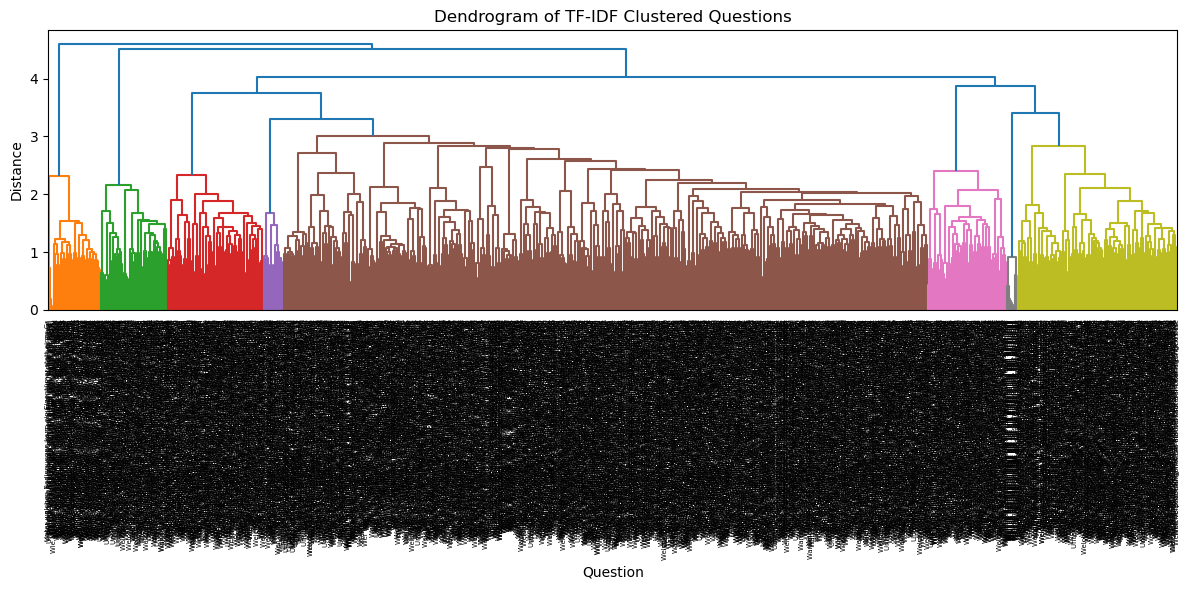

✅ Clustered 1736 questions into 125 clusters.
✅ Clustered questions saved as clustered_cq_TF_rthema.json.


In [16]:
n_clusters = 125
clusters_with_rthema = cluster_and_plot_cq(Z, question_rthema_pairs, n_clusters=n_clusters)

# Save the clustered questions to a JSON file, therefore clean at first 
clusters_with_rthema_cleaned = {int(k): v for k, v in clusters_with_rthema.items()}

# Save to JSON
with open("competency_questions_output/clustered_cq_TF_rthema.json", "w", encoding="utf-8") as f:
    json.dump(clusters_with_rthema_cleaned, f, ensure_ascii=False, indent=4)

print(f"✅ Clustered {sum(len(v) for v in clusters_with_rthema.values())} questions into {len(clusters_with_rthema)} clusters.")
print("✅ Clustered questions saved as clustered_cq_TF_rthema.json.")


Compare with the clustering results when rthema is not included "competency_questions_output/clustered_cq_TF.json" 

Using: 
- Silhouette Score with +1 = well-matched; -1 = badly matched
- Purity Score, the higher the better semantic coherence

In [17]:
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from collections import Counter
import numpy as np

Load both data sets

In [18]:
with open("competency_questions_output/clustered_cq_TF_rthema.json", "r", encoding="utf-8") as f:
    clusters_with_rthema = json.load(f)

with open("competency_questions_output/clustered_cq_TF.json", "r", encoding="utf-8") as f:
    clusters_without_rthema = json.load(f)

Reconstruct the question lists

In [19]:
questions_with_rthema = []
labels_with = []

for cluster_id, items in clusters_with_rthema.items():
    for item in items:
        full_q = f"{item['rthema']}: {item['question']}".strip()
        questions_with_rthema.append(full_q)
        labels_with.append(int(cluster_id))

# Without rthema
questions_without_rthema = []
labels_without = []

for cluster_id, questions in clusters_without_rthema.items():
    for q in questions:
        questions_without_rthema.append(q.strip())
        labels_without.append(int(cluster_id))

assert len(questions_with_rthema) == len(labels_with)
assert len(questions_without_rthema) == len(labels_without)

Compute TF IDF Matrices

In [20]:
vectorizer = TfidfVectorizer()
X_with = vectorizer.fit_transform(questions_with_rthema)
X_without = vectorizer.fit_transform(questions_without_rthema)


Compute Silhouette scores
Including the rechtsthema slightly increased the overall score, so added some value in spearating semanticvally closer questions -> slight improve of structureal cohesion of the clusters

In [21]:
score_with = silhouette_score(X_with, labels_with, metric='cosine')
score_without = silhouette_score(X_without, labels_without, metric='cosine')

print(f"🔍 Silhouette Score WITH Rechtsthema:    {score_with:.4f}")
print(f"🔍 Silhouette Score WITHOUT Rechtsthema: {score_without:.4f}")

🔍 Silhouette Score WITH Rechtsthema:    0.0710
🔍 Silhouette Score WITHOUT Rechtsthema: 0.0565


Compute the purity for clusters with rthema

On average 63% of the questions in each cluster share the same Rechtsthema, suggesting that the including rechtsthema helps to group semantically related questions. 

In [22]:
def compute_rthema_purity(clusters):
    purities = []
    for cluster in clusters.values():
        rthemas = [q["rthema"] for q in cluster]
        if not rthemas:
            continue
        most_common = Counter(rthemas).most_common(1)[0][1]
        purity = most_common / len(rthemas)
        purities.append(purity)
    return sum(purities) / len(purities)

purity_with = compute_rthema_purity(clusters_with_rthema)
print(f"📊 Average rthema purity in clusters (with rthema): {purity_with:.4f}")


📊 Average rthema purity in clusters (with rthema): 0.6348
